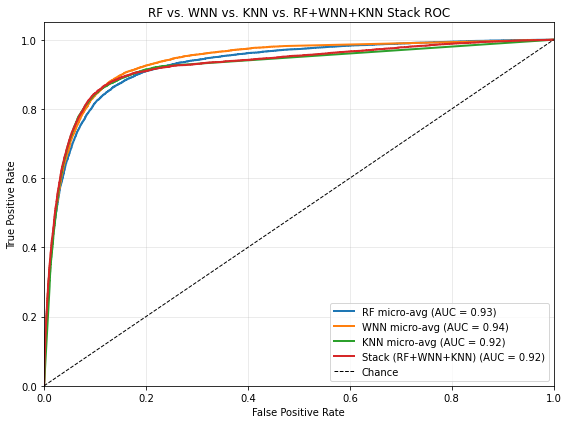

In [2]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

# 1) Load & preprocess
df = pd.read_csv('soil_csv_pre-processed.csv')
X = pd.get_dummies(df.drop(columns=['Disease_Type']), drop_first=True)
y = df['Disease_Type']

# 2) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# 3) Binarize the test labels once
classes    = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)

# --- Random Forest ---
rf = RandomForestClassifier(
    n_estimators=326,
    max_depth=25,
    max_features=None,
    min_samples_split=2,
    min_samples_leaf=3,
    random_state=42
)
rf.fit(X_train, y_train)
y_proba_rf  = rf.predict_proba(X_test)
fpr_rf, tpr_rf, _ = roc_curve(y_test_bin.ravel(), y_proba_rf.ravel())
auc_rf      = auc(fpr_rf, tpr_rf)

# --- Weighted KNN (original) ---
wnn = KNeighborsClassifier(
    algorithm='ball_tree',
    leaf_size=50,
    metric='minkowski',
    p=1,
    n_neighbors=11,
    weights='distance'
)
wnn.fit(X_train, y_train)
y_proba_wnn = wnn.predict_proba(X_test)
fpr_wnn, tpr_wnn, _ = roc_curve(y_test_bin.ravel(), y_proba_wnn.ravel())
auc_wnn     = auc(fpr_wnn, tpr_wnn)

# ... your preprocessing, rf and wnn code as before ...

best_params = {
    'algorithm':  'ball_tree',
    'leaf_size':   10,
    'n_neighbors':  5,
    'p':            1,
    'weights':    'distance'
}

# --- Optimized KNN (from your best_params) ---
knn = KNeighborsClassifier(**best_params)
knn.fit(X_train, y_train)
y_proba_knn = knn.predict_proba(X_test)
fpr_knn, tpr_knn, _ = roc_curve(y_test_bin.ravel(), y_proba_knn.ravel())
auc_knn = auc(fpr_knn, tpr_knn)

# --- Stacking of RF + WNN + KNN ---
estimators = [
    ('rf',  rf),
    ('wnn', wnn),
    ('knn', knn)
]
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    stack_method='predict_proba'
)
stack.fit(X_train, y_train)
y_proba_stack = stack.predict_proba(X_test)
fpr_stack, tpr_stack, _ = roc_curve(y_test_bin.ravel(), y_proba_stack.ravel())
auc_stack = auc(fpr_stack, tpr_stack)

# --- Plot all four curves ---
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf,    tpr_rf,    lw=2, label=f'RF micro-avg (AUC = {auc_rf:.2f})')
plt.plot(fpr_wnn,   tpr_wnn,   lw=2, label=f'WNN micro-avg (AUC = {auc_wnn:.2f})')
plt.plot(fpr_knn,   tpr_knn,   lw=2, label=f'KNN micro-avg (AUC = {auc_knn:.2f})')
plt.plot(fpr_stack, tpr_stack, lw=2, label=f'Stack (RF+WNN+KNN) (AUC = {auc_stack:.2f})')
plt.plot([0,1], [0,1], 'k--', lw=1, label='Chance')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('RF vs. WNN vs. KNN vs. RF+WNN+KNN Stack ROC')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import joblib

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- Load dataset ---
df = pd.read_csv("soil_csv_pre-processed.csv")
X_raw = df.drop(columns=["Disease_Type"])
y_raw = df["Disease_Type"]

# --- One-hot encode input ---
X_encoded = pd.get_dummies(X_raw)
columns = X_encoded.columns.tolist()  # Save for consistent prediction later
joblib.dump(columns, "X_encoded_columns.pkl")

# --- Label encode target ---
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
joblib.dump(label_encoder, "label_encoder.pkl")

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, stratify=y, random_state=42)

# --- Feature scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
joblib.dump(scaler, "scaler.pkl")

# --- Define base learners ---
rf = RandomForestClassifier(
    n_estimators=326,
    max_depth=25,
    max_features=None,
    min_samples_split=2,
    min_samples_leaf=3,
    random_state=42
)

wnn = KNeighborsClassifier(
    algorithm='ball_tree',
    leaf_size=50,
    metric='minkowski',
    p=1,
    n_neighbors=11,
    weights='distance'
)

best_params = {
    'algorithm':  'ball_tree',
    'leaf_size':  10,
    'n_neighbors': 5,
    'p': 1,
    'weights': 'distance'
}
knn = KNeighborsClassifier(**best_params)

# --- Define stacking model ---
estimators = [
    ('rf',  rf),
    ('wnn', wnn),
    ('knn', knn)
]
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    stack_method='predict_proba'
)

# --- Fit model ---
stack.fit(X_train_scaled, y_train)
joblib.dump(stack, "stack_model.pkl")
joblib.dump(X_train.columns.tolist(), "X_encoded_columns.pkl")



print("✅ Model training and saving complete.")


✅ Model training and saving complete.



🔍 Results for Random Forest
✅ Accuracy: 0.7357363998230871

📋 Classification Report:
                          precision    recall  f1-score   support

                  Cancer     0.7293    0.7368    0.7330      1850
Gastrointestinal Disease     0.7473    0.7127    0.7296      1730
   Neurological Disorder     0.7484    0.7372    0.7428      1796
      Respiratory Issues     0.7155    0.7237    0.7196      1741
            Skin Disease     0.7388    0.7649    0.7517      1927

                accuracy                         0.7357      9044
               macro avg     0.7359    0.7351    0.7353      9044
            weighted avg     0.7359    0.7357    0.7357      9044

📈 ROC AUC (micro): 0.9282
📈 ROC AUC (macro): 0.9282
📊 Avg Precision (micro): 0.7878

🔍 Results for WNN (k=11)
✅ Accuracy: 0.7467934542237947

📋 Classification Report:
                          precision    recall  f1-score   support

                  Cancer     0.7437    0.7465    0.7451      1850
Gastrointestinal 

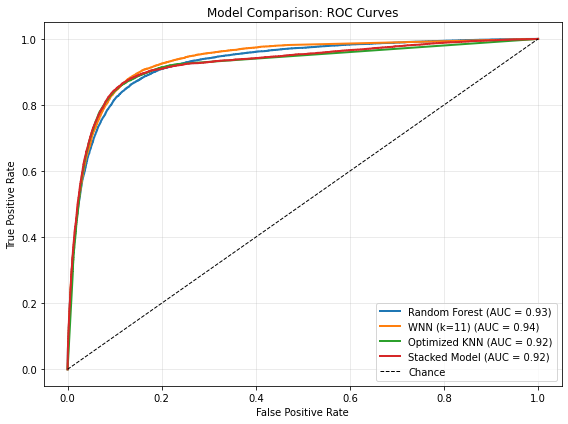

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    auc
)
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

def evaluate_model(name, model, X_test, y_test_bin, y_test_labels, classes):
    """Evaluate a classifier and print all metrics."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    print(f"\n🔍 Results for {name}")
    print("✅ Accuracy:", accuracy_score(y_test_labels, y_pred))

    print("\n📋 Classification Report:")
    print(classification_report(y_test_labels, y_pred, target_names=classes, digits=4))

    auc_micro = roc_auc_score(y_test_bin, y_proba, average='micro')
    auc_macro = roc_auc_score(y_test_bin, y_proba, average='macro')
    ap_micro  = average_precision_score(y_test_bin, y_proba, average='micro')

    print(f"📈 ROC AUC (micro): {auc_micro:.4f}")
    print(f"📈 ROC AUC (macro): {auc_macro:.4f}")
    print(f"📊 Avg Precision (micro): {ap_micro:.4f}")

    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
    return fpr, tpr, auc(fpr, tpr)

def main():
    # Load & preprocess
    df = pd.read_csv("soil_csv_pre-processed.csv")
    X = pd.get_dummies(df.drop(columns=['Disease_Type']), drop_first=True)
    y = df['Disease_Type']
    classes = sorted(y.unique())

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )
    y_test_bin = label_binarize(y_test, classes=classes)

    # --- Define models ---
    rf = RandomForestClassifier(
        n_estimators=326, max_depth=25, max_features=None,
        min_samples_split=2, min_samples_leaf=3, random_state=42
    )
    rf.fit(X_train, y_train)

    wnn = KNeighborsClassifier(
        algorithm='ball_tree', leaf_size=50, metric='minkowski',
        p=1, n_neighbors=11, weights='distance'
    )
    wnn.fit(X_train, y_train)

    best_params = {
        'algorithm':  'ball_tree',
        'leaf_size':  10,
        'n_neighbors': 5,
        'p': 1,
        'weights': 'distance'
    }
    knn = KNeighborsClassifier(**best_params)
    knn.fit(X_train, y_train)

    estimators = [('rf', rf), ('wnn', wnn), ('knn', knn)]
    stack = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=1000, random_state=42),
        cv=5,
        stack_method='predict_proba'
    )
    stack.fit(X_train, y_train)

    # --- Evaluate & collect ROC data ---
    results = []
    for name, model in [
        ("Random Forest", rf),
        ("WNN (k=11)", wnn),
        ("Optimized KNN", knn),
        ("Stacked Model", stack)
    ]:
        fpr, tpr, auc_val = evaluate_model(name, model, X_test, y_test_bin, y_test, classes)
        results.append((name, fpr, tpr, auc_val))

    # --- Plot ROC curves ---
    plt.figure(figsize=(8, 6))
    for name, fpr, tpr, auc_val in results:
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc_val:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1, label="Chance")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Model Comparison: ROC Curves')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()
